In [ ]:
# ============================================================
# LUNG DISEASE PREDICTION SYSTEM
# GOOGLE COLAB + T4 GPU
# MODEL UPLOAD + MULTIPLE IMAGE PREDICTION
# ============================================================

import os
import io
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from google.colab import files

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.densenet import preprocess_input


# ============================================================
# GPU SETUP
# ============================================================

print("=" * 60)
print("CHECKING GOOGLE COLAB GPU")
print("=" * 60)

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print("\nGPU detected:")

    for gpu in gpus:
        print(" ", gpu)

    try:

        for gpu in gpus:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print("\nGPU memory growth enabled.")

    except RuntimeError as e:

        print(
            f"\nGPU configuration warning: {e}"
        )

else:

    print("\nWARNING: No GPU detected.")
    print(
        "Go to Runtime -> Change runtime type -> "
        "select T4 GPU."
    )


# ============================================================
# UPLOAD AND LOAD MODEL
# ============================================================

def upload_model():

    print("\n")
    print("=" * 60)
    print("STEP 1 - UPLOAD TRAINED MODEL")
    print("=" * 60)

    print(
        "\nSelect your trained .keras model."
    )

    uploaded = files.upload()

    if not uploaded:

        print("\nNo model uploaded.")

        return None

    # --------------------------------------------------------
    # Find .keras file
    # --------------------------------------------------------

    keras_files = [
        filename
        for filename in uploaded.keys()
        if filename.lower().endswith(".keras")
    ]

    if not keras_files:

        print(
            "\nERROR: No .keras model found."
        )

        return None

    model_filename = keras_files[0]

    print(
        f"\nModel selected:\n  {model_filename}"
    )

    # --------------------------------------------------------
    # Model size
    # --------------------------------------------------------

    size_mb = (
        os.path.getsize(model_filename)
        / (1024 * 1024)
    )

    print(
        f"Model size: {size_mb:.2f} MB"
    )

    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    print(
        "\nLoading model..."
    )

    start_time = time.time()

    try:

        model = load_model(
            model_filename,
            compile=False
        )

    except Exception as e:

        print(
            "\nERROR while loading model:"
        )

        print(e)

        return None

    elapsed = time.time() - start_time

    print(
        "\nModel loaded successfully!"
    )

    print(
        f"Loading time: {elapsed:.2f} seconds"
    )

    # --------------------------------------------------------
    # Model information
    # --------------------------------------------------------

    print("\nModel Information:")

    print(
        f"Input shape : {model.input_shape}"
    )

    print(
        f"Output shape: {model.output_shape}"
    )

    # --------------------------------------------------------
    # Number of classes
    # --------------------------------------------------------

    number_of_classes = (
        model.output_shape[-1]
    )

    print(
        f"\nNumber of output classes: "
        f"{number_of_classes}"
    )

    # --------------------------------------------------------
    # GPU warm-up
    # --------------------------------------------------------

    print(
        "\nWarming up model..."
    )

    try:

        input_shape = model.input_shape

        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]

        dummy = np.zeros(
            (
                1,
                height,
                width,
                channels
            ),
            dtype=np.float32
        )

        model.predict(
            dummy,
            verbose=0
        )

        print(
            "Model warm-up completed."
        )

    except Exception as e:

        print(
            f"Warm-up warning: {e}"
        )

    return model


# ============================================================
# GET CLASS NAMES
# ============================================================

def get_class_names(number_of_classes):

    print("\n")
    print("=" * 60)
    print("STEP 2 - ENTER MODEL CLASS NAMES")
    print("=" * 60)

    print(
        f"\nYour model has "
        f"{number_of_classes} output classes."
    )

    print(
        "\nEnter the class names in the EXACT order "
        "used when training the model."
    )

    print(
        "\nExample:"
    )

    print(
        "COVID-19, Normal, Pneumonia, "
        "Tuberculosis, Lung_Opacity"
    )

    print(
        "\nIMPORTANT:"
    )

    print(
        "The order matters."
    )

    print(
        "Do NOT alphabetically reorder the classes "
        "unless that is how your model was trained."
    )

    while True:

        class_input = input(
            "\nEnter class names separated by commas:\n"
        ).strip()

        if not class_input:

            print(
                "Please enter the class names."
            )

            continue

        class_names = [
            name.strip()
            for name in class_input.split(",")
            if name.strip()
        ]

        if len(class_names) != number_of_classes:

            print(
                f"\nERROR:"
            )

            print(
                f"Your model has "
                f"{number_of_classes} outputs."
            )

            print(
                f"You entered "
                f"{len(class_names)} classes."
            )

            print(
                f"Please enter exactly "
                f"{number_of_classes} names."
            )

            continue

        break

    print("\nClass mapping:")

    for index, class_name in enumerate(
        class_names
    ):

        print(
            f"  {index} -> {class_name}"
        )

    return class_names


# ============================================================
# PREPARE IMAGE
# ============================================================

def prepare_image(
    content,
    target_size=(224, 224)
):

    image = Image.open(
        io.BytesIO(content)
    ).convert("RGB")

    original = np.array(image)

    height, width = original.shape[:2]

    resized = cv2.resize(
        original,
        target_size,
        interpolation=cv2.INTER_AREA
    )

    resized = resized.astype(
        np.float32
    )

    processed = preprocess_input(
        resized
    )

    return (
        original,
        processed,
        width,
        height
    )


# ============================================================
# PREDICT IMAGE BATCH
# ============================================================

def predict_images(
    model,
    class_names,
    uploaded_images
):

    filenames = list(
        uploaded_images.keys()
    )

    processed_images = []

    original_images = {}

    valid_filenames = []

    print(
        "\nPreparing uploaded images..."
    )

    # ========================================================
    # PREPROCESS
    # ========================================================

    for filename in filenames:

        try:

            (
                original,
                processed,
                width,
                height
            ) = prepare_image(
                uploaded_images[filename]
            )

            processed_images.append(
                processed
            )

            original_images[filename] = (
                original,
                width,
                height
            )

            valid_filenames.append(
                filename
            )

        except Exception as e:

            print(
                f"\nSkipping {filename}"
            )

            print(
                f"Reason: {e}"
            )

    if not processed_images:

        print(
            "\nNo valid images found."
        )

        return None

    # ========================================================
    # CREATE BATCH
    # ========================================================

    image_batch = np.stack(
        processed_images,
        axis=0
    )

    print(
        f"\nImages prepared: "
        f"{len(image_batch)}"
    )

    # ========================================================
    # PREDICT
    # ========================================================

    print(
        "\nRunning prediction..."
    )

    start_time = time.time()

    predictions = model.predict(
        image_batch,
        batch_size=32,
        verbose=0
    )

    elapsed = (
        time.time() - start_time
    )

    print(
        f"Prediction completed in "
        f"{elapsed:.2f} seconds."
    )

    # ========================================================
    # RESULTS
    # ========================================================

    results = []

    for index, filename in enumerate(
        valid_filenames
    ):

        prediction = predictions[index]

        predicted_index = int(
            np.argmax(prediction)
        )

        predicted_class = (
            class_names[predicted_index]
        )

        confidence = (
            float(
                prediction[predicted_index]
            ) * 100
        )

        # ----------------------------------------------------
        # Display image
        # ----------------------------------------------------

        original, width, height = (
            original_images[filename]
        )

        plt.figure(
            figsize=(7, 6)
        )

        plt.imshow(
            original
        )

        plt.title(
            f"{filename}\n"
            f"Prediction: {predicted_class}\n"
            f"Confidence: {confidence:.2f}%"
        )

        plt.axis("off")

        plt.show()

        # ----------------------------------------------------
        # Print result
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)
        print(
            f"IMAGE {index + 1}: {filename}"
        )
        print("=" * 60)

        print(
            f"Prediction : {predicted_class}"
        )

        print(
            f"Confidence : {confidence:.2f}%"
        )

        print(
            "\nClass probabilities:"
        )

        # Sort probabilities
        probability_pairs = sorted(
            zip(
                class_names,
                prediction
            ),
            key=lambda x: x[1],
            reverse=True
        )

        for class_name, probability in (
            probability_pairs
        ):

            print(
                f"  {class_name:<25}"
                f"{probability * 100:>7.2f}%"
            )

        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        result = {
            "Image": filename,
            "Prediction": predicted_class,
            "Confidence": confidence
        }

        for class_index, class_name in enumerate(
            class_names
        ):

            result[
                class_name
            ] = float(
                prediction[class_index]
            ) * 100

        results.append(result)

    # ========================================================
    # SUMMARY TABLE
    # ========================================================

    results_df = pd.DataFrame(
        results
    )

    print("\n")
    print("=" * 60)
    print("PREDICTION SUMMARY")
    print("=" * 60)

    display(
        results_df
    )

    return results_df


# ============================================================
# MAIN SYSTEM
# ============================================================

def lung_disease_prediction_system():

    print("\n")
    print("=" * 60)
    print("       LUNG DISEASE PREDICTION SYSTEM")
    print("=" * 60)

    # ========================================================
    # MODEL
    # ========================================================

    model = upload_model()

    if model is None:

        print(
            "\nPrediction system stopped."
        )

        return

    # ========================================================
    # CLASS NAMES
    # ========================================================

    number_of_classes = (
        model.output_shape[-1]
    )

    class_names = get_class_names(
        number_of_classes
    )

    # ========================================================
    # MODEL READY
    # ========================================================

    print("\n")
    print("=" * 60)
    print("MODEL READY FOR PREDICTION")
    print("=" * 60)

    print(
        "\nThe model is loaded."
    )

    print(
        "You can now upload images."
    )

    print(
        "You can upload multiple images "
        "at the same time."
    )

    print(
        "After every batch you can continue "
        "uploading more images."
    )

    # ========================================================
    # CONTINUOUS LOOP
    # ========================================================

    while True:

        print("\n")
        print("=" * 60)
        print("UPLOAD IMAGES")
        print("=" * 60)

        print(
            "\nUpload one or more:"
        )

        print(
            "  JPG"
        )

        print(
            "  JPEG"
        )

        print(
            "  PNG"
        )

        uploaded = files.upload()

        if not uploaded:

            print(
                "\nNo files uploaded."
            )

            choice = input(
                "Try again? (y/n): "
            ).strip().lower()

            if choice in [
                "n",
                "no",
                "q",
                "quit",
                "cancel"
            ]:

                break

            continue

        # ----------------------------------------------------
        # Filter image files
        # ----------------------------------------------------

        image_files = {}

        for filename, content in (
            uploaded.items()
        ):

            extension = (
                os.path.splitext(
                    filename
                )[1].lower()
            )

            if extension in [
                ".jpg",
                ".jpeg",
                ".png"
            ]:

                image_files[
                    filename
                ] = content

            else:

                print(
                    f"\nSkipping unsupported file:"
                    f" {filename}"
                )

        if not image_files:

            print(
                "\nNo valid image files."
            )

            continue

        print(
            f"\n{len(image_files)} "
            f"image(s) selected."
        )

        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        predict_images(
            model,
            class_names,
            image_files
        )

        # ----------------------------------------------------
        # CONTINUE
        # ----------------------------------------------------

        print("\n")
        print("=" * 60)

        choice = input(
            "Do you want to upload more images? "
            "(y/n): "
        ).strip().lower()

        if choice in [
            "n",
            "no",
            "q",
            "quit",
            "cancel",
            "exit"
        ]:

            print("\n")
            print("=" * 60)
            print(
                "PREDICTION SESSION COMPLETED"
            )
            print("=" * 60)

            break

        print(
            "\nReady for the next batch..."
        )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    gc.collect()

    print(
        "\nModel remains loaded until "
        "the Colab runtime is reset."
    )


# ============================================================
# RUN
# ============================================================

print("\n")
print("=" * 60)
print("PROGRAM READY")
print("=" * 60)

print(
    "\nRun this command:"
)

print(
    "lung_disease_prediction_system()"
)

CHECKING GOOGLE COLAB GPU

GPU detected:
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU memory growth enabled.


PROGRAM READY

Run this command:
lung_disease_prediction_system()




       LUNG DISEASE PREDICTION SYSTEM


STEP 1 - UPLOAD TRAINED MODEL

Select your trained .keras model.


Saving lung_disease_model.keras to lung_disease_model (5).keras

Model selected:
  lung_disease_model (5).keras
Model size: 30.02 MB

Loading model...

Model loaded successfully!
Loading time: 1.13 seconds

Model Information:
Input shape : (None, 224, 224, 3)
Output shape: (None, 5)

Number of output classes: 5

Warming up model...


Model warm-up completed.


STEP 2 - ENTER MODEL CLASS NAMES

Your model has 5 output classes.

Enter the class names in the EXACT order used when training the model.

Example:
COVID-19, Normal, Pneumonia, Tuberculosis, Lung_Opacity

IMPORTANT:
The order matters.
Do NOT alphabetically reorder the classes unless that is how your model was trained.

Enter class names separated by commas:
Covid, Tuberclosis, Bacterial Pnemonia, Normal, Viral Pnemonia

Class mapping:
  0 -> Covid
  1 -> Tuberclosis
  2 -> Bacterial Pnemonia
  3 -> Normal
  4 -> Viral Pnemonia


MODEL READY FOR PREDICTION

The model is loaded.
You can now upload images.
You can upload multiple images at the same time.
After every batch you can continue uploading more images.


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving Covid.jpg to Covid (1).jpg
Saving TB.png to TB (1).png
Saving TB.gif to TB (1).gif
Saving TB.jpeg to TB (1).jpeg
Saving Normal.jpg to Normal (1).jpg

Skipping unsupported file: TB (1).gif

4 image(s) selected.

Preparing uploaded images...

Images prepared: 4

Running prediction...


Prediction completed in 4.86 seconds.


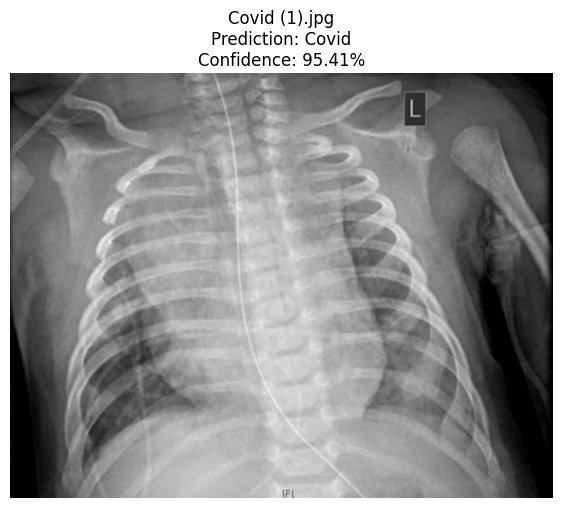



IMAGE 1: Covid (1).jpg
Prediction : Covid
Confidence : 95.41%

Class probabilities:
  Covid                      95.41%
  Viral Pnemonia              4.55%
  Bacterial Pnemonia          0.04%
  Normal                      0.00%
  Tuberclosis                 0.00%


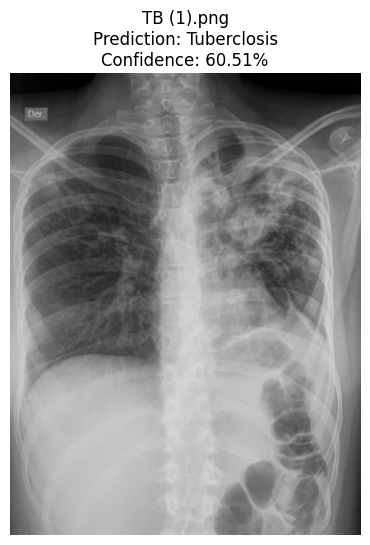



IMAGE 2: TB (1).png
Prediction : Tuberclosis
Confidence : 60.51%

Class probabilities:
  Tuberclosis                60.51%
  Normal                     39.34%
  Covid                       0.09%
  Viral Pnemonia              0.03%
  Bacterial Pnemonia          0.03%


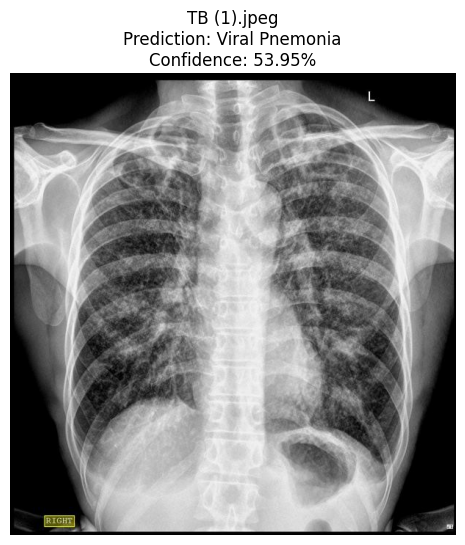



IMAGE 3: TB (1).jpeg
Prediction : Viral Pnemonia
Confidence : 53.95%

Class probabilities:
  Viral Pnemonia             53.95%
  Covid                      44.51%
  Bacterial Pnemonia          1.36%
  Tuberclosis                 0.12%
  Normal                      0.06%


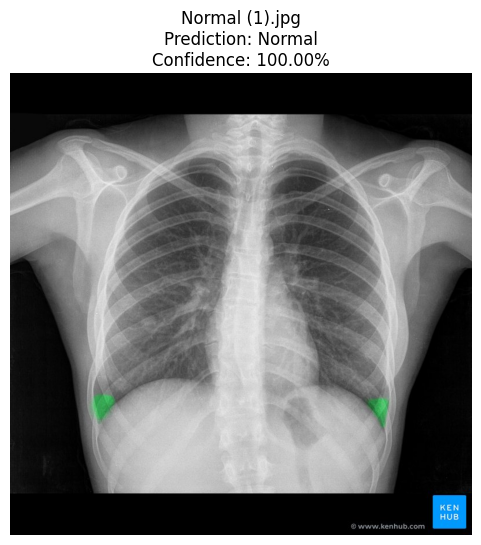



IMAGE 4: Normal (1).jpg
Prediction : Normal
Confidence : 100.00%

Class probabilities:
  Normal                    100.00%
  Tuberclosis                 0.00%
  Bacterial Pnemonia          0.00%
  Covid                       0.00%
  Viral Pnemonia              0.00%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,Covid (1).jpg,Covid,95.411354,95.411354,0.000066,0.042555,0.000071,4.545962e+00
1,TB (1).png,Tuberclosis,60.510498,0.093420,60.510498,0.026107,39.337370,3.261516e-02
2,TB (1).jpeg,Viral Pnemonia,53.952432,44.510341,0.116937,1.363295,0.057003,5.395243e+01
3,Normal (1).jpg,Normal,99.999905,0.000001,0.000083,0.000013,99.999905,2.427306e-07




Do you want to upload more images? (y/n): y

Ready for the next batch...


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery.jpeg to 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery.jpeg

1 image(s) selected.

Preparing uploaded images...

Images prepared: 1

Running prediction...
Prediction completed in 0.08 seconds.


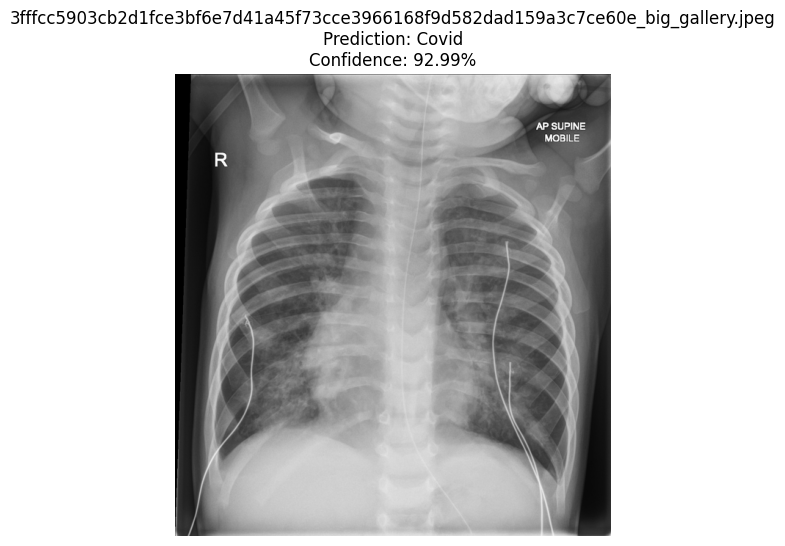



IMAGE 1: 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery.jpeg
Prediction : Covid
Confidence : 92.99%

Class probabilities:
  Covid                      92.99%
  Viral Pnemonia              7.00%
  Bacterial Pnemonia          0.01%
  Tuberclosis                 0.00%
  Normal                      0.00%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d...,Covid,92.994553,92.994553,0.001705,0.005159,0.000393,6.998199




Do you want to upload more images? (y/n): y

Ready for the next batch...


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery.jpeg to 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery (1).jpeg

1 image(s) selected.

Preparing uploaded images...

Images prepared: 1

Running prediction...
Prediction completed in 0.08 seconds.


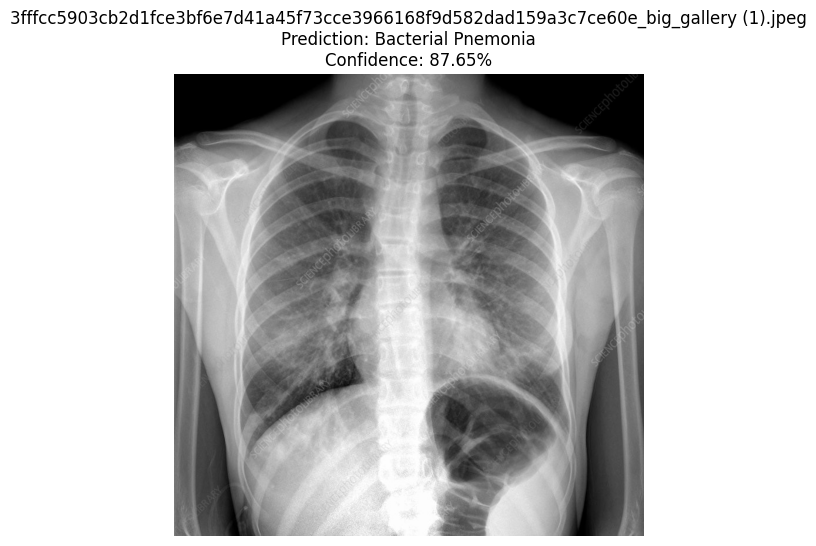



IMAGE 1: 3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d582dad159a3c7ce60e_big_gallery (1).jpeg
Prediction : Bacterial Pnemonia
Confidence : 87.65%

Class probabilities:
  Bacterial Pnemonia         87.65%
  Tuberclosis                 7.44%
  Normal                      3.05%
  Viral Pnemonia              1.21%
  Covid                       0.66%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,3fffcc5903cb2d1fce3bf6e7d41a45f73cce3966168f9d...,Bacterial Pnemonia,87.649351,0.657292,7.437842,87.649351,3.046784,1.208734




Do you want to upload more images? (y/n): y

Ready for the next batch...


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving images.jpg to images (1).jpg

1 image(s) selected.

Preparing uploaded images...

Images prepared: 1

Running prediction...
Prediction completed in 0.09 seconds.


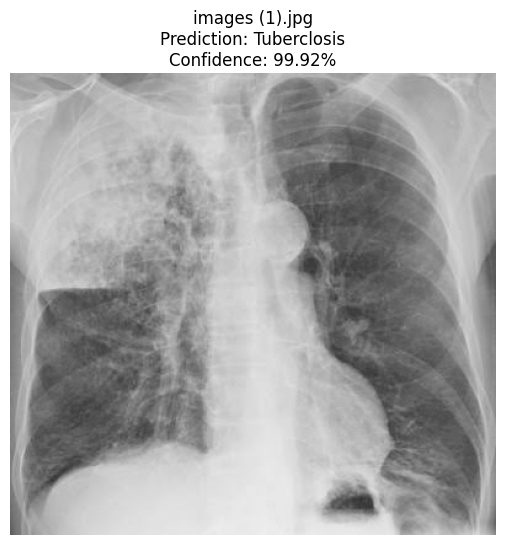



IMAGE 1: images (1).jpg
Prediction : Tuberclosis
Confidence : 99.92%

Class probabilities:
  Tuberclosis                99.92%
  Normal                      0.07%
  Covid                       0.00%
  Bacterial Pnemonia          0.00%
  Viral Pnemonia              0.00%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,images (1).jpg,Tuberclosis,99.923193,0.00317,99.923193,0.000111,0.073478,0.000052




Do you want to upload more images? (y/n): y

Ready for the next batch...


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving images.jpg to images (2).jpg

1 image(s) selected.

Preparing uploaded images...

Images prepared: 1

Running prediction...
Prediction completed in 0.11 seconds.


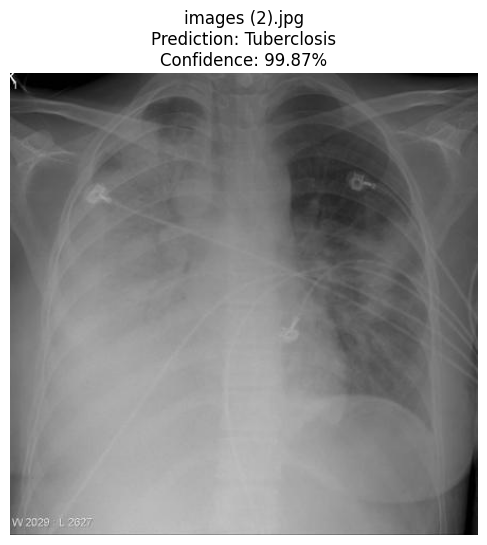



IMAGE 1: images (2).jpg
Prediction : Tuberclosis
Confidence : 99.87%

Class probabilities:
  Tuberclosis                99.87%
  Covid                       0.11%
  Normal                      0.02%
  Viral Pnemonia              0.01%
  Bacterial Pnemonia          0.00%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,images (2).jpg,Tuberclosis,99.866271,0.10526,99.866271,0.000134,0.016232,0.012102




Do you want to upload more images? (y/n): y

Ready for the next batch...


UPLOAD IMAGES

Upload one or more:
  JPG
  JPEG
  PNG


Saving images.jpg to images (3).jpg

1 image(s) selected.

Preparing uploaded images...

Images prepared: 1

Running prediction...
Prediction completed in 0.08 seconds.


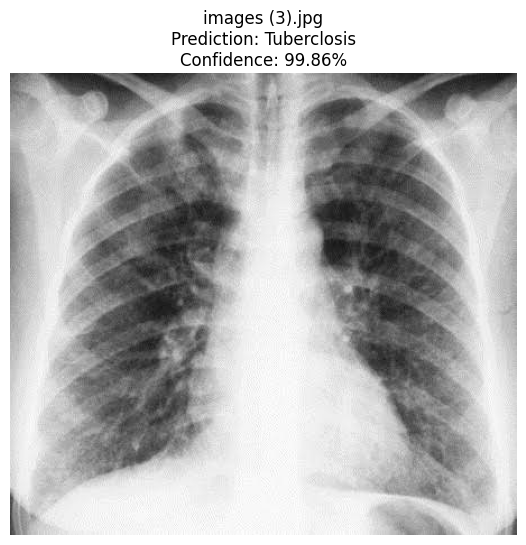



IMAGE 1: images (3).jpg
Prediction : Tuberclosis
Confidence : 99.86%

Class probabilities:
  Tuberclosis                99.86%
  Normal                      0.11%
  Bacterial Pnemonia          0.01%
  Covid                       0.01%
  Viral Pnemonia              0.01%


PREDICTION SUMMARY


,Image,Prediction,Confidence,Covid,Tuberclosis,Bacterial Pnemonia,Normal,Viral Pnemonia
0,images (3).jpg,Tuberclosis,99.856359,0.011303,99.856359,0.012269,0.113821,0.006238




Do you want to upload more images? (y/n): n


PREDICTION SESSION COMPLETED

Model remains loaded until the Colab runtime is reset.


In [6]:
lung_disease_prediction_system()

Covid, Tuberclosis, Viral Pnemonia, Normal, Bacterial Pnemonia